In [1]:
!pip install albumentations opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 MB 2.1 MB/s  0:00:22m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 MB 2.0 MB/s  0:00:23m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 3.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [albumentations]m [albucore]thon]headless]


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A

In [7]:
def load_image(path):
    image = cv2.imread(path)
    if image is None:
        raise FileNotFoundError(f"Не вдалося знайти файл: {path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

In [8]:
image_path = "image.jpg"
image = load_image(image_path)

In [9]:
def display_image(image, title="Image", figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()

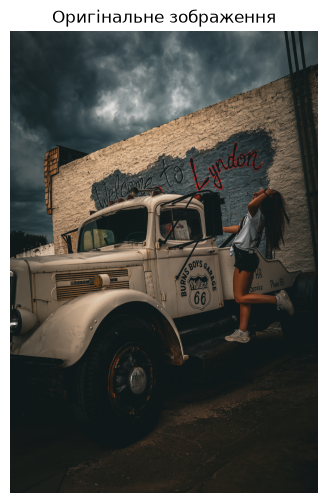

In [10]:
display_image(image, "Оригінальне зображення")

In [11]:
def resize_image(image, width=300, height=300):
    return cv2.resize(image, (width, height))

In [12]:
def rotate_image(image, angle=45):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)

    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, matrix, (w, h))
    return rotated

In [13]:
def flip_image(image, mode=1):
    mode = 1
    mode = 0
    mode = -1
    return cv2.flip(image, mode)

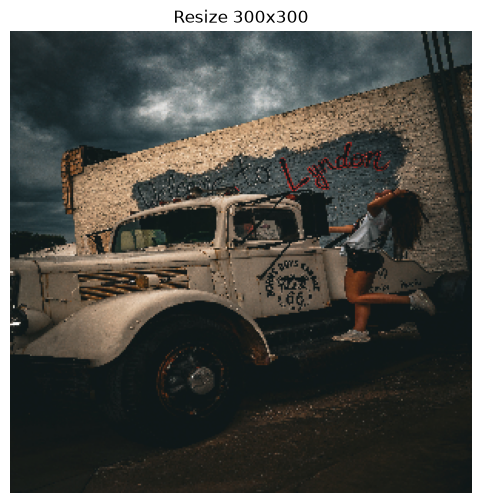

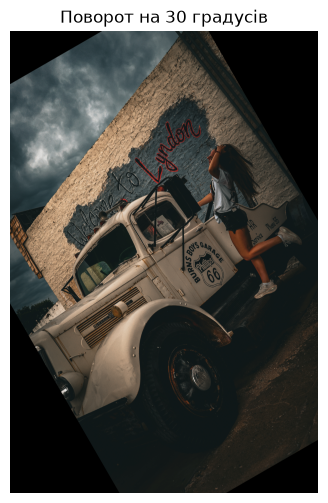

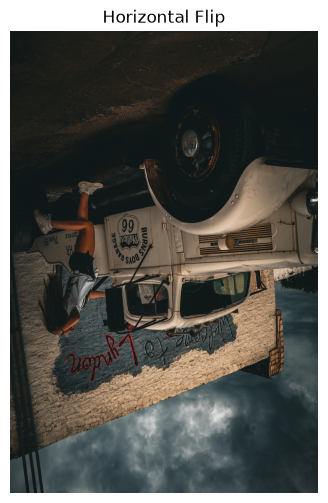

In [14]:
resized = resize_image(image, 300, 300)
rotated = rotate_image(image, 30)
flipped = flip_image(image, 1)
display_image(resized, "Resize 300x300")
display_image(rotated, "Поворот на 30 градусів")
display_image(flipped, "Horizontal Flip")

In [15]:
augmentation = A.Compose([
    A.RandomCrop(height=250, width=250, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.7),
    A.GaussNoise(p=0.5),
    A.Rotate(limit=25, p=0.5)
])

In [16]:
def augment_image(image):
    result = augmentation(image=image)
    return result["image"]

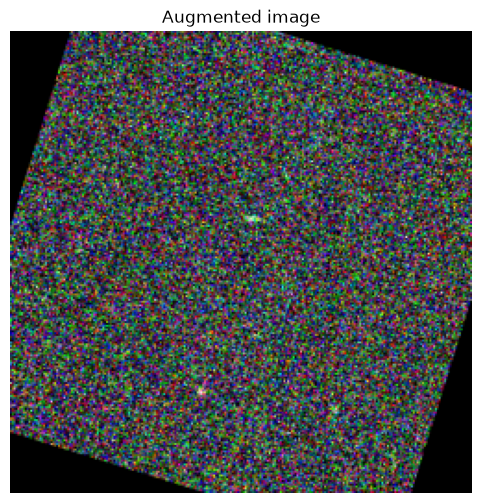

In [17]:
augmented = augment_image(image)
display_image(augmented, "Augmented image")

In [18]:
def compare_images(images, titles):
    count = len(images)
    plt.figure(figsize=(5 * count, 5))

    for i, img in enumerate(images):
        plt.subplot(1, count, i + 1)
        plt.imshow(img)
        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

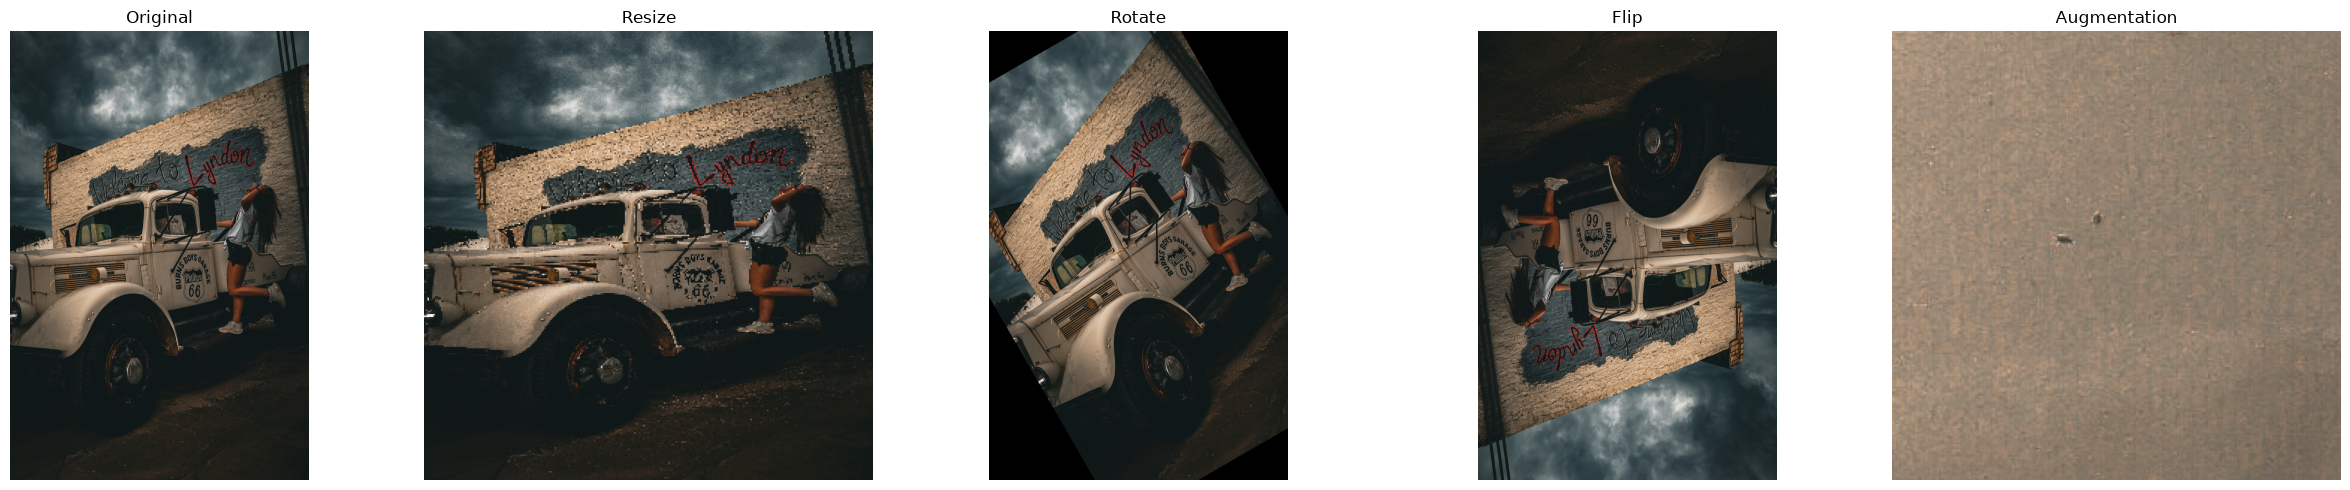

In [19]:
resized = resize_image(image, 300, 300)
rotated = rotate_image(image, 30)
flipped = flip_image(image)
augmented = augment_image(image)

compare_images(
    [image, resized, rotated, flipped, augmented],
    ["Original", "Resize", "Rotate", "Flip", "Augmentation"]
)

In [20]:
def show_multiple_augmentations(image, n=4):
    plt.figure(figsize=(12, 8))

    for i in range(n):
        aug_image = augment_image(image)

        plt.subplot(2, 2, i + 1)
        plt.imshow(aug_image)
        plt.title(f"Augmentation {i + 1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

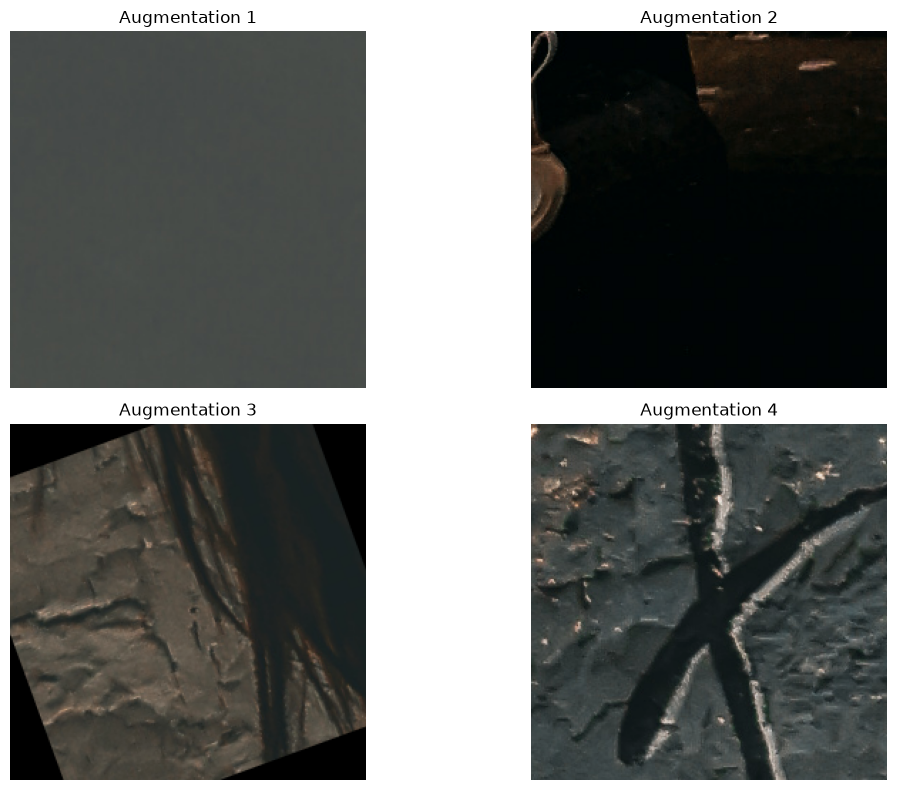

In [21]:
show_multiple_augmentations(image)

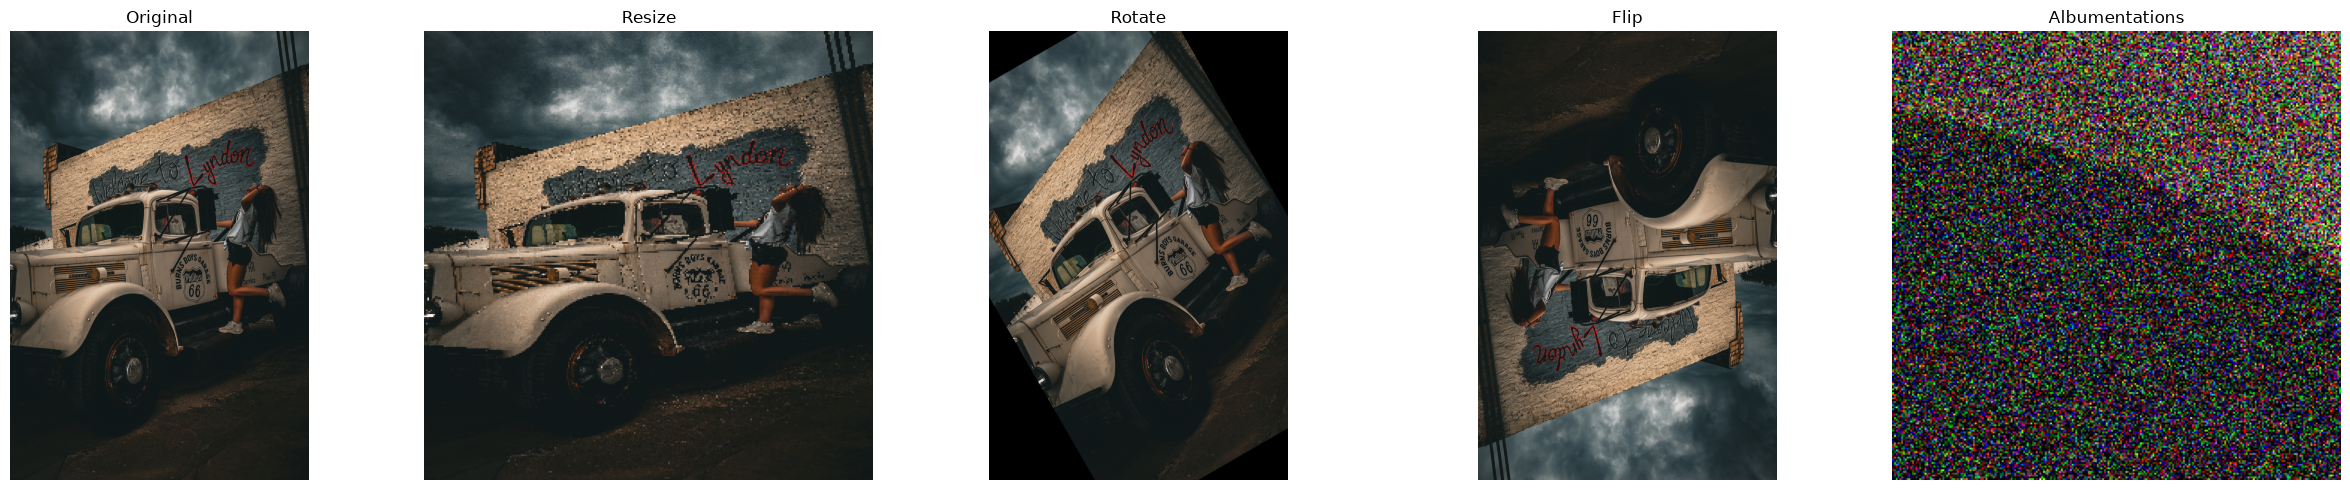

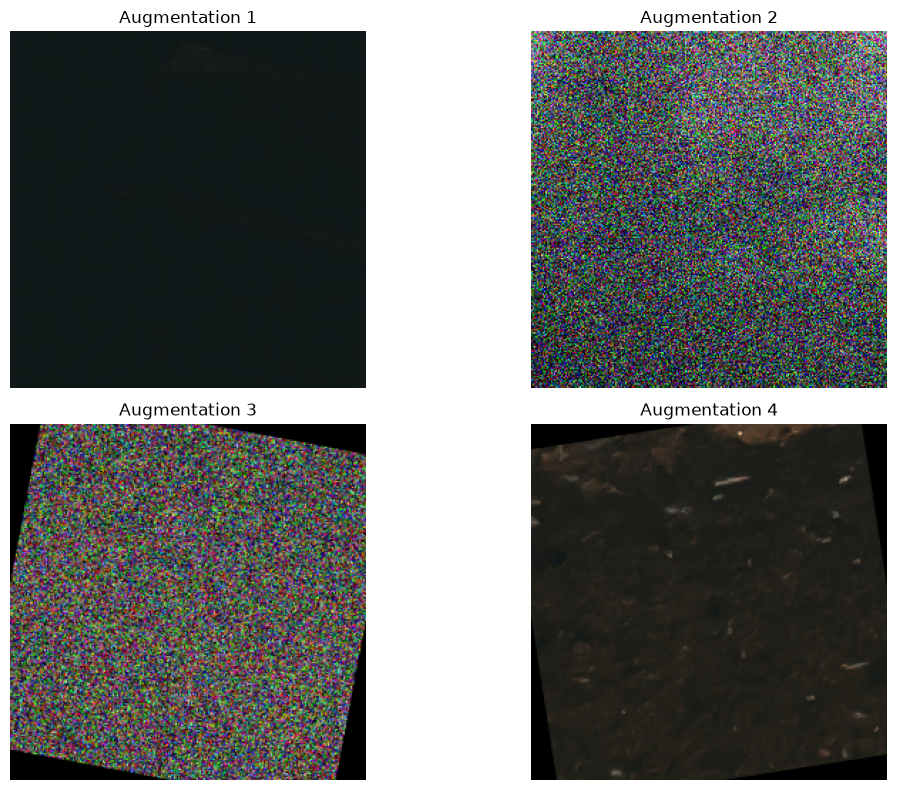

In [22]:
image = load_image("image.jpg")
resized = resize_image(image, 300, 300)
rotated = rotate_image(image, 30)
flipped = flip_image(image, 1)
augmented = augment_image(image)
compare_images(
    [image, resized, rotated, flipped, augmented],
    ["Original", "Resize", "Rotate", "Flip", "Albumentations"]
)
show_multiple_augmentations(image)